# 08 - EchoNext exploratory data analysis

EchoNext (Columbia University Irving Medical Center, PhysioNet release 1.1.0) has 100,000 twelve-lead ECGs of
adults, each labeled with **structural heart disease measured on an echocardiogram**: a weak heart muscle
(ejection fraction 45% or less), thick walls, moderate or severe valve disease, high pulmonary pressure,
right-ventricle dysfunction or a large pericardial effusion. Every other project label comes from reading the
ECG itself; this one comes from an independent test of the heart. This notebook describes the release: its
splits, missing values, labels and how they relate to the patients, and what the waveforms contain.

EchoNext is credentialed data, so the notebook shows **aggregate statistics only**, never an individual ECG
or row. The test split stays closed: only its counts are read, never its waveforms or labels. Everything is
read straight from the downloaded ZIP; the analysis code is in `ecg_experiment/eda/echonext.py`.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ecg_experiment.eda import echonext
from ecg_experiment.eda.cross import combined_summary
from ecg_experiment.eda.sph import load_metadata as load_sph
from ecg_experiment.eda.sph import sph_summary
from ecg_experiment.eda.stats import age_band, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

meta = echonext.load_metadata()
open_meta = meta[meta["split"].isin(echonext.OPEN_SPLITS)].copy()
print(f"{len(meta):,} ECGs, {meta['patient_key'].nunique():,} patients")

100,000 ECGs, 36,286 patients


## 1. Splits and patients

In [3]:
splits = meta.groupby("split").agg(ECGs=("patient_key", "size"), patients=("patient_key", "nunique"),
                                   most_recent_share=("most_recent_ecg", "mean"))
splits["ECGs per patient"] = splits["ECGs"] / splits["patients"]
display(splits.loc[echonext.SPLITS].round(3))
display(echonext.split_overlap(meta).rename_axis(index="patients shared"))
display(meta.groupby("split")["acquisition_year"].agg(["min", "median", "max"]).loc[echonext.SPLITS])

,ECGs,patients,most_recent_share,ECGs per patient
split,,,,
train,72475,26218,0.362,2.764
val,4626,4626,1.000,1.000
test,5442,5442,1.000,1.000
no_split,17457,4618,0.000,3.780


,train,val,test,no_split
patients shared,,,,
train,26218,0,0,0
val,0,4626,0,2119
test,0,0,5442,2499
no_split,0,2119,2499,4618


,min,median,max
split,,,
train,2008,2016.0,2022
val,2008,2017.0,2022
test,2008,2017.0,2022
no_split,2008,2016.0,2022


**Finding: patient-disjoint splits, but `no_split` belongs to the held-out patients.**

- 100,000 ECGs of 36,286 patients. Training has 72,475 ECGs of 26,218 patients (2.8 per patient), while
  validation (4,626) and test (5,442) keep exactly one ECG per patient, always that patient's most recent one.
- Training shares no patient with any other split. The 17,457 `no_split` ECGs are all older ECGs of 4,618
  patients, and those patients are validation (2,119) or test (2,499) patients. `no_split` must not be used
  for training.
- Every split spans 2008 to 2022.

## 2. Missing values

In [4]:
demographic = ["age_at_ecg", "sex", "race_ethnicity", "location_setting", *echonext.MEASUREMENTS]
echo = list(dict.fromkeys(echonext.COMPONENTS.values()))
missing = pd.concat([meta.groupby("split")[demographic + echo].apply(lambda frame: frame.isna().mean()).T],
                    axis=1)[echonext.SPLITS]
display(missing[missing.max(axis=1) > 0].round(3))
display(meta["race_ethnicity"].value_counts(normalize=True).round(3).to_frame("share").T)
recent = open_meta.groupby("split")["lvef_value"].apply(lambda values: values.notna().mean())
print("Share of open ECGs with an echo measurement:", recent.round(3).to_dict())

split,train,val,test,no_split
atrial_rate,0.006,0.007,0.008,0.005
pr_interval,0.105,0.101,0.095,0.101
qt_corrected,0.000,0.000,0.000,0.000
lvef_value,0.089,0.111,0.113,0.078
ivs_measurement,0.091,0.113,0.115,0.078
aortic_stenosis_value,0.090,0.112,0.114,0.079
aortic_regurgitation_value,0.090,0.112,0.114,0.079
mitral_regurgitation_value,0.090,0.111,0.114,0.078
tricuspid_regurgitation_value,0.090,0.111,0.114,0.079
pulmonary_regurgitation_value,0.089,0.111,0.113,0.078


race_ethnicity,hispanic,white,black,unknown,other,asian
share,0.31,0.292,0.165,0.125,0.074,0.034


Share of open ECGs with an echo measurement: {'train': 0.911, 'val': 0.889}


**Finding: demographics and cart measurements are complete; echo values are not.**

- Age, sex, race, setting, rate, QRS and QTc are never missing. Atrial rate is missing for under 1% of ECGs
  and PR for about 10%.
- The echo values are missing for 9-11% of ECGs in train and val, pericardial effusion for 12-14%, pulmonary
  pressure (PASP) for 43-51% and tricuspid velocity for 55-64%. These are ECGs without an echo within a
  year: 91.1% of train and 88.9% of val ECGs have an ejection-fraction value.
- The population is diverse: 31% Hispanic, 29% white, 17% Black, 3% Asian, 7% other and 13% unknown.

## 3. Labels

The release documents that ECGs taken before an echo with no structural disease are labeled negative, and
that the component labels are only filled for ECGs taken within a year before an echo. How do the binary
labels relate to the echo values they come from?

In [5]:
display(echonext.label_consistency(meta).fillna("").rename_axis("all splits"))
flags = [echonext.COMPOSITE, *echonext.COMPONENTS]
rates = open_meta.groupby("split")[flags].mean().T
rates["train positives"] = open_meta[open_meta["split"] == "train"][flags].sum()
rates["val positives"] = open_meta[open_meta["split"] == "val"][flags].sum()
display(rates.round(3))
components = open_meta[list(echonext.COMPONENTS)].sum(axis=1)
positive = open_meta[echonext.COMPOSITE] == 1
display(components[positive].value_counts().sort_index().rename("positive ECGs with this many components")
        .to_frame().T)
train = open_meta[open_meta["split"] == "train"]
display(pd.Series({
    "train, all ECGs": train[echonext.COMPOSITE].mean(),
    "train, most recent ECG of each patient": train.loc[train["most_recent_ecg"] == 1,
                                                        echonext.COMPOSITE].mean(),
    "train, patients with 1 ECG": train.loc[train["ecgs_of_patient"] == 1, echonext.COMPOSITE].mean(),
    "train, patients with 5+ ECGs": train.loc[train["ecgs_of_patient"] >= 5, echonext.COMPOSITE].mean(),
    "val": open_meta.loc[open_meta["split"] == "val", echonext.COMPOSITE].mean(),
}).round(3).rename("composite positive share").to_frame())

,positives,positive_without_value,negative_without_value,disagrees_with_threshold,positive_without_any_component,component_without_composite
all splits,,,,,,
lvef_lte_45_flag,23892,0.0,8944.0,0.0,,
lvwt_gte_13_flag,24220,11.0,9122.0,0.0,,
aortic_stenosis_moderate_or_greater_flag,4054,0.0,9003.0,,,
aortic_regurgitation_moderate_or_greater_flag,1264,0.0,9003.0,,,
mitral_regurgitation_moderate_or_greater_flag,8451,0.0,9000.0,,,
tricuspid_regurgitation_moderate_or_greater_flag,10651,0.0,9036.0,,,
pulmonary_regurgitation_moderate_or_greater_flag,821,0.0,8944.0,,,
rv_systolic_dysfunction_moderate_or_greater_flag,13243,0.0,9096.0,,,
pericardial_effusion_moderate_large_flag,3023,0.0,11823.0,,,


split,train,val,train positives,val positives
shd_moderate_or_greater_flag,0.524,0.430,37958,1990
lvef_lte_45_flag,0.234,0.187,16962,866
lvwt_gte_13_flag,0.244,0.190,17667,877
aortic_stenosis_moderate_or_greater_flag,0.040,0.054,2919,252
aortic_regurgitation_moderate_or_greater_flag,0.012,0.013,878,62
mitral_regurgitation_moderate_or_greater_flag,0.085,0.061,6137,282
tricuspid_regurgitation_moderate_or_greater_flag,0.106,0.066,7707,305
pulmonary_regurgitation_moderate_or_greater_flag,0.008,0.005,603,21
rv_systolic_dysfunction_moderate_or_greater_flag,0.132,0.080,9597,368
pericardial_effusion_moderate_large_flag,0.029,0.011,2079,52


,1,2,3,4,5,6,7,8,9
positive ECGs with this many components,17411,9491,5351,3643,2338,1178,395,109,32


,composite positive share
"train, all ECGs",0.524
"train, most recent ECG of each patient",0.435
"train, patients with 1 ECG",0.397
"train, patients with 5+ ECGs",0.611
val,0.430


**Finding: consistent labels, where "negative" sometimes means "not measured".**

- The composite label is exactly the "or" of the eleven components: no positive lacks a component and no
  component lacks the composite. Where the echo value is present, the four numeric labels agree with their
  documented thresholds without exception.
- A component is set to 0 when its echo value is missing: 43,424 PASP negatives and 54,996 tricuspid
  velocity negatives have no measurement. Component labels are only meaningful where the value exists.
- Training ECGs are more often positive than validation ECGs: 52.4% against 43.0% for the composite, and
  higher for almost every component. This comes from repeat ECGs: patients with five or more training ECGs
  are 61.1% positive, patients with one ECG 39.7%, and the most recent training ECG of each patient is
  43.5% positive, the same as validation.
- Most positives have one component (17,411), but many have several, up to nine.

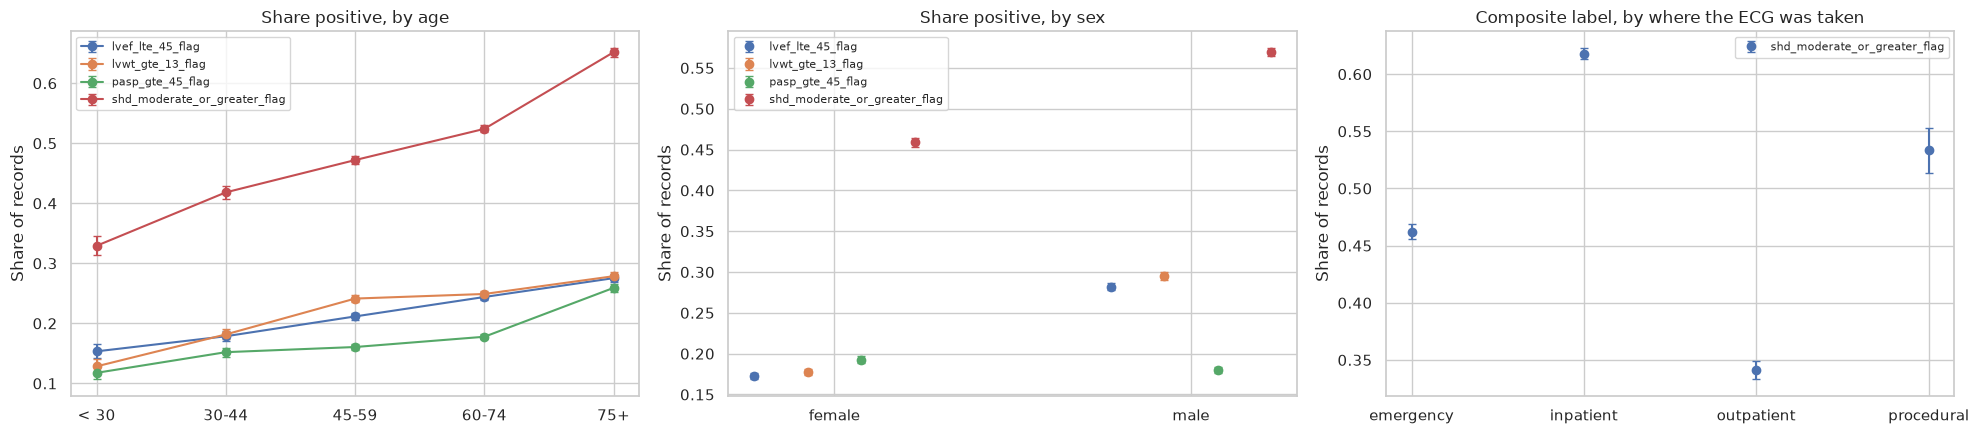

,outcome,predictor,odds_ratio,lower,upper,p_value
0,shd_moderate_or_greater_flag,age per 10 years,1.255,1.243,1.267,0.0
1,shd_moderate_or_greater_flag,male,1.612,1.566,1.659,0.0
2,lvef_lte_45_flag,age per 10 years,1.145,1.132,1.158,0.0
3,lvef_lte_45_flag,male,1.913,1.847,1.981,0.0
4,lvwt_gte_13_flag,age per 10 years,1.140,1.127,1.152,0.0
5,lvwt_gte_13_flag,male,1.970,1.903,2.039,0.0
6,pasp_gte_45_flag,age per 10 years,1.182,1.168,1.196,0.0
7,pasp_gte_45_flag,male,0.932,0.898,0.967,0.0


acquisition_year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
size,132.000,3107.000,4205.000,4180.00,4446.000,5250.000,5594.000,5739.000,6571.000,7439.000,6239.000,4536.00,5678.000,7279.00,6706.000
mean,0.326,0.501,0.518,0.48,0.496,0.477,0.494,0.508,0.511,0.501,0.495,0.52,0.545,0.57,0.597


In [6]:
open_meta["age_band"] = age_band(open_meta["age_at_ecg"])
open_meta["male"] = open_meta["sex"] == "male"
main = [echonext.COMPOSITE, "lvef_lte_45_flag", "lvwt_gte_13_flag", "pasp_gte_45_flag"]
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
plot_prevalence(prevalence(open_meta, "age_band", main), "age_band", axes[0], "Share positive, by age")
plot_prevalence(prevalence(open_meta, "sex", main), "sex", axes[1], "Share positive, by sex", connect=False)
plot_prevalence(prevalence(open_meta, "location_setting", [echonext.COMPOSITE]), "location_setting", axes[2],
                "Composite label, by where the ECG was taken", connect=False)
plt.tight_layout()
plt.show()
display(odds_ratios(open_meta.rename(columns={"age_at_ecg": "age"}), main).round(3))
display(open_meta.groupby("acquisition_year")[echonext.COMPOSITE].agg(["size", "mean"]).round(3).T)

**Finding: disease rises with age, is more common in men and in hospital ECGs.**

- The composite rises from about 33% under 30 to about 65% at 75 and over (odds 1.26 per decade). Men have
  1.6 times the odds; for a weak ventricle (LVEF 45% or less) and thick walls the odds ratio is about 1.9,
  while high pulmonary pressure is slightly less common in men (0.93).
- The setting matters as much as age: about 62% of inpatient ECGs are positive, against about 34% of
  outpatient ECGs.
- Prevalence is about 48-52% from 2009 to 2019 and rises to 57% in 2021 and 60% in 2022.

## 4. The cart measurements

Each ECG comes with the cart's heart rate and intervals. How different are they between ECGs with and
without structural disease?

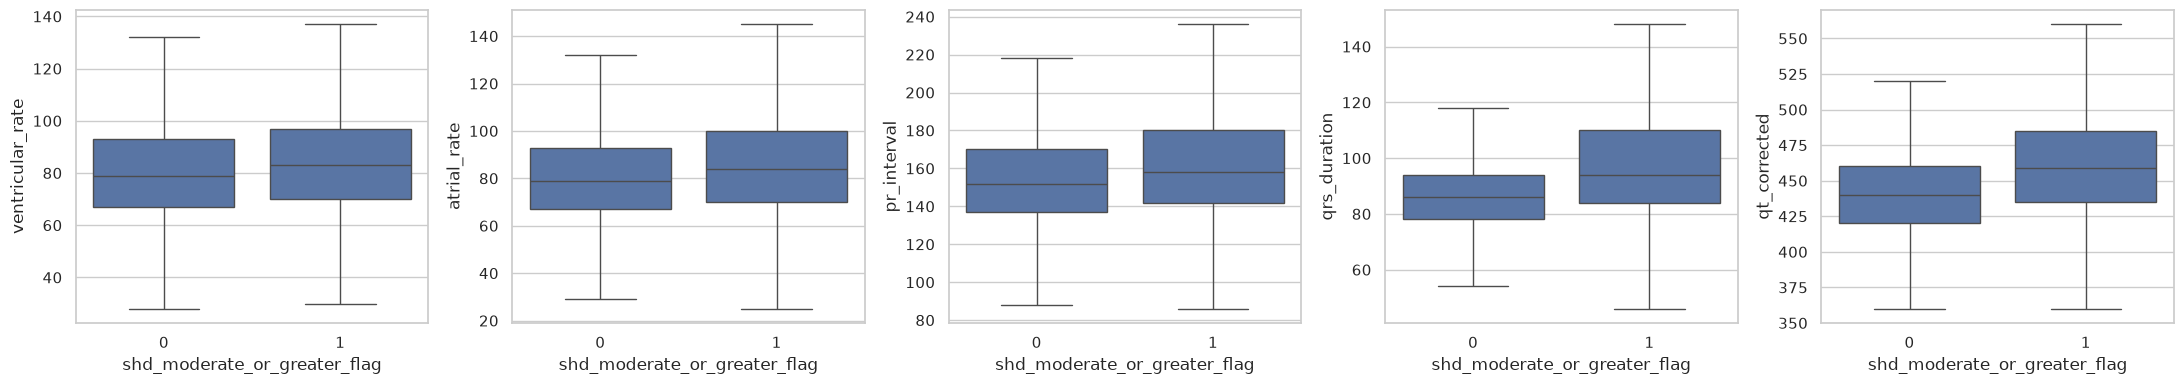

,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected
shd_moderate_or_greater_flag,,,,,
0,79.0,79.0,152.0,86.0,440.0
1,83.0,84.0,158.0,94.0,459.0


In [7]:
measure = open_meta.melt(id_vars=[echonext.COMPOSITE], value_vars=echonext.MEASUREMENTS)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for axis, name in zip(axes, echonext.MEASUREMENTS, strict=True):
    sns.boxplot(open_meta, x=echonext.COMPOSITE, y=name, showfliers=False, ax=axis)
plt.tight_layout()
plt.show()
display(open_meta.groupby(echonext.COMPOSITE)[echonext.MEASUREMENTS].median().round(1))

**Finding: the cart measurements differ by label, but overlap a lot.** Positive ECGs have longer QRS
(median 94 against 86 ms) and QTc (459 against 440 ms), a slightly longer PR (158 against 152 ms) and a
slightly faster rate (83 against 79 bpm). The distributions overlap widely, so these numbers alone separate
the classes only partly; they are the natural baseline for any waveform model on this label.

## 5. Waveforms

The waveforms were median filtered, clipped at the 0.1 and 99.9 percentiles and standardized by the
authors. Their values have no unit, so amplitude rules in mV do not apply. What do the preprocessed
signals look like?

In [8]:
records = {}
for split in echonext.OPEN_SPLITS:
    features, digest = echonext.waveform_features(split)
    records[split] = echonext.record_table(features).assign(split=split)
    print(f"{split}: {len(records[split]):,} waveforms, SHA-256 matches the release ({digest[:12]}...)")
waves = pd.concat(records.values())
display(waves[["std", "mean", "peak_abs", "bound_fraction", "einthoven_residual", "heart_rate"]]
        .describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).round(3).T)
display(pd.Series({
    "records with a constant lead": int((waves["constant_leads"] > 0).sum()),
    "records with a lead flat for 1 s": int((waves["flat_leads"] > 0).sum()),
    "records with a nonfinite value": int(waves["std"].isna().sum()),
    "heart rate not estimated": int(waves["heart_rate"].isna().sum()),
}).to_frame("records"))

train: 72,475 waveforms, SHA-256 matches the release (f966bb602f93...)
val: 4,626 waveforms, SHA-256 matches the release (28db27137032...)


,count,mean,std,min,0.1%,1%,50%,99%,99.9%,max
std,77101.0,0.808,0.304,0.110,0.227,0.320,0.753,1.789,2.406,3.946
mean,77101.0,-0.002,0.084,-0.721,-0.350,-0.221,-0.004,0.222,0.321,0.495
peak_abs,77101.0,7.754,1.973,0.682,2.236,3.223,7.943,10.715,10.715,10.715
bound_fraction,77101.0,0.001,0.003,0.001,0.001,0.001,0.001,0.013,0.037,0.115
einthoven_residual,77101.0,0.812,1.055,0.077,0.118,0.157,0.446,5.473,8.450,11.360
heart_rate,77100.0,83.467,20.711,23.401,35.885,47.022,80.863,144.231,174.419,200.000


,records
records with a constant lead,4
records with a lead flat for 1 s,643
records with a nonfinite value,0
heart rate not estimated,1


**Finding: standardized, clipped signals with no missing values.** All 77,101 train and val
waveforms match the release checksums, and none has a nonfinite sample. The median lead has standard
deviation 0.75 and mean 0 (standardized units), and the largest value in any record is 10.715, the clipping
bound. The limb identities hold only approximately (median residual 0.45 standardized units), as expected when
each lead is scaled separately. 4 records have a constant lead and 643 have a lead constant for at least 1 s.

### Leads with a constant stretch

Some records have leads that stay exactly constant for a second or more. Where in the recording is the
constant stretch, and at which value?

In [9]:
runs = pd.concat([
    echonext.flat_runs(split, set(records[split].index[records[split]["flat_leads"] > 0])).assign(split=split)
    for split in echonext.OPEN_SPLITS])
runs["flat"] = runs["length"] >= echonext.SAMPLING_RATE
per_record = runs.groupby(["split", "row"])["flat"].sum()
display(per_record.value_counts().sort_index().rename("records").rename_axis("leads with a 1 s constant run")
        .to_frame().T)
full = runs.set_index(["split", "row"]).loc[per_record[per_record == 12].index].reset_index()
pattern = full.groupby("lead", sort=False).agg(
    start_s=("start", lambda values: values.median() / echonext.SAMPLING_RATE),
    length_s=("length", lambda values: values.median() / echonext.SAMPLING_RATE),
    share_at_median=("length", lambda values: (values == values.median()).mean()),
    distinct_values=("value", lambda values: values.round(3).nunique()))
display(pattern.round(3).T)
flagged = open_meta.reset_index().set_index(["split", "row"]).loc[per_record[per_record == 12].index]
print(f"All-lead records: {len(flagged):,}; composite positive {flagged[echonext.COMPOSITE].mean():.1%} "
      f"vs {open_meta[echonext.COMPOSITE].mean():.1%} overall")
display(flagged["acquisition_year"].value_counts().sort_index().rename("records").to_frame().T)
display(flagged["location_setting"].value_counts(normalize=True).round(3).rename("share").to_frame().T)

leads with a 1 s constant run,1,7,12
records,13,1,629


lead,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
start_s,5.000,5.000,5.000,5.000,5.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000
length_s,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,7.500,7.500,7.500
share_at_median,0.876,0.878,0.819,0.908,0.835,0.865,0.901,0.889,0.895,0.908,0.911,0.906
distinct_values,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


All-lead records: 629; composite positive 26.2% vs 51.8% overall


acquisition_year,2008,2009,2010,2011,2012,2021
records,18,323,114,64,107,3


location_setting,inpatient,outpatient,emergency
share,0.596,0.399,0.005


**Finding: 629 records have only part of each lead.** In 629 records, all twelve leads contain a long
constant stretch, and it follows one fixed pattern: the limb leads are constant from 5 s to 10 s, V1-V3 from
0 to 5 s, and V4-V6 from 0 to 7.5 s (82-91% of these records match the median exactly). Each lead's constant
value is the same in every record, so it is a filler, not a signal. These ECGs therefore contain 5 s of limb
leads, 5 s of V1-V3 and 2.5 s of V4-V6, recorded at different times.

The pattern is tied to the recording period, not to the heart: 626 of the 629 come from 2008-2012, and
only 26.2% are positive, against 51.8% overall. A model could learn "filled leads mean healthy". Another 14
records have one or seven such leads.

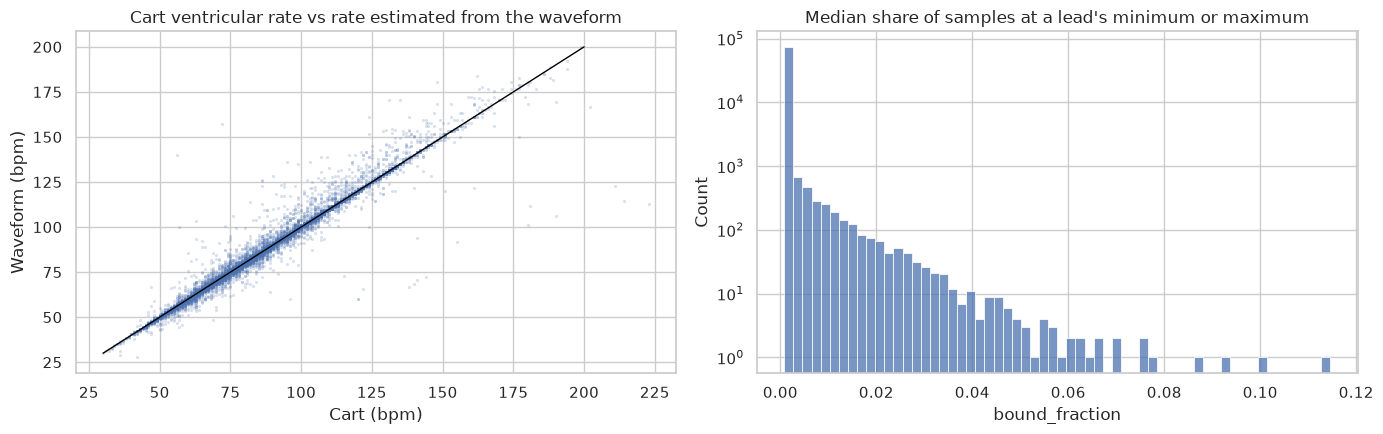

Waveform rate within 10 bpm of the cart rate: 98.4%; correlation 0.985


In [10]:
joined = pd.concat([records[split].join(open_meta[open_meta["split"] == split].reset_index()
                                        .set_index("row")[["ventricular_rate", "patient_key"]])
                    for split in echonext.OPEN_SPLITS])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sample = joined.sample(20000, random_state=0)
sns.scatterplot(sample, x="ventricular_rate", y="heart_rate", s=4, alpha=0.2, edgecolor=None, ax=axes[0])
axes[0].plot([30, 200], [30, 200], color="black", linewidth=1)
axes[0].set(title="Cart ventricular rate vs rate estimated from the waveform", xlabel="Cart (bpm)",
            ylabel="Waveform (bpm)")
sns.histplot(waves["bound_fraction"], bins=60, ax=axes[1])
axes[1].set(title="Median share of samples at a lead's minimum or maximum", yscale="log")
plt.tight_layout()
plt.show()
agree = (joined["heart_rate"] - joined["ventricular_rate"]).abs() <= 10
print(f"Waveform rate within 10 bpm of the cart rate: {agree.mean():.1%}; "
      f"correlation {joined[['heart_rate', 'ventricular_rate']].corr().iloc[0, 1]:.3f}")

**Finding: the waveforms match their metadata.** The heart rate estimated from the waveform is within
10 bpm of the cart's ventricular rate for 98.4% of ECGs (correlation 0.985), so each waveform row belongs to
its metadata row. Most records have about 0.1% of samples at a lead's minimum or maximum; a small tail has
more, up to 11%.

In [11]:
hashes = joined["signal_sha256"]
duplicated = joined[hashes.duplicated(keep=False)]
by_hash = duplicated.groupby("signal_sha256")
display(pd.Series({
    "groups of identical waveforms": by_hash.ngroups,
    "waveforms in them": len(duplicated),
    "groups spanning train and val": int(by_hash["split"].nunique().gt(1).sum()),
    "groups from more than one patient": int(by_hash["patient_key"].nunique().gt(1).sum()),
}).to_frame("count"))

,count
groups of identical waveforms,0
waveforms in them,0
groups spanning train and val,0
groups from more than one patient,0


**Finding: no duplicates.** No two train or val waveforms are identical, within or across splits.

## 6. How the signals were filtered

The share of power below 0.7 Hz (baseline wander), at 50 or 60 Hz (mains) and above 40 Hz does not depend on
the amplitude unit, so it can be compared with the other sources.

In [12]:
others = combined_summary()
sph = sph_summary(load_sph()).assign(source="sph")
columns = ["baseline_fraction", "powerline_50_fraction", "powerline_60_fraction", "high_frequency_fraction",
           "heart_rate"]
table = pd.concat([others[["source", *columns]], sph[["source", *columns]],
                   waves[columns].assign(source="echonext")])
display(table.groupby("source")[columns].median().round(5).sort_values("baseline_fraction"))

,baseline_fraction,powerline_50_fraction,powerline_60_fraction,high_frequency_fraction,heart_rate
source,,,,,
sph,0.00057,0.00024,0.00013,0.00324,72.11538
echonext,0.00102,0.00099,0.00053,0.00989,80.86253
cpsc_2018_extra,0.00600,0.00049,0.00021,0.00498,76.62835
cpsc_2018,0.00652,0.00054,0.00024,0.00550,76.92308
mimic,0.00830,0.00099,0.00054,0.01121,74.62687
ptbxl,0.01990,0.00071,0.00032,0.00663,71.25891
code15,0.02289,0.00011,0.00003,0.00140,71.00592
chapman_shaoxing,0.02320,0.00119,0.00057,0.01217,73.52941
georgia,0.02385,0.00082,0.00040,0.00790,75.28231


**Finding: heavily filtered, like SPH.** EchoNext keeps 20 times less power below 0.7 Hz than PTB-XL
(0.0010 against 0.0199), the second lowest after SPH, consistent with the documented median filtering. Its
power in the 50 and 60 Hz bands and above 40 Hz is almost the same as MIMIC's, the other US hospital source.
Its median heart rate (81 bpm) is the highest of all sources, as expected for a mostly hospital population.

## 7. Conclusions about the dataset

- **Format.** Ten-second, twelve-lead, 250 Hz waveforms in standard lead order, already median filtered,
  clipped and standardized, with no physical unit. Metadata and waveforms match, and there are no duplicates
  or missing samples.
- **Splits.** Train, val and test are patient-disjoint. `no_split` holds older ECGs of val and test patients.
- **Labels.** The echo-based labels are internally consistent. Component negatives often mean "not
  measured", and training is more often positive than validation because it keeps all of each patient's ECGs.
  Disease rises with age, is more common in men, and depends strongly on the care setting.
- **Problems.** 629 records (0.8%) carry only 2.5-5 s of each lead, filled with a constant; they are mostly
  from 2009-2012 and are much more often negative, so they can act as a shortcut.
- **Filtering.** Like SPH, EchoNext is much smoother at low frequencies than PTB-XL.